# Imports

In [7]:
import matplotlib.pyplot as plt
#%matplotlib qt
import numpy as np
import pandas as pd
import seaborn as sns
import math

from pyriemann.estimation import XdawnCovariances
from pyriemann.tangentspace import TangentSpace

from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, validation_curve, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, make_scorer, confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report, roc_curve, auc, precision_score, recall_score

### Metrics function

In [8]:
def calculate_metrics(df, experiment_name):

    results_table = []

    for subject, group in df.groupby('subject'):
        y_true = group['y_true']
        y_pred = group['y_pred']
        
        acc = balanced_accuracy_score(y_true, y_pred) * 100
        f1 = f1_score(y_true, y_pred, pos_label=0)
        precision = precision_score(y_true, y_pred, pos_label=0)
        recall = recall_score(y_true, y_pred, pos_label=0)
        
        results_table.append({
            'Experiment': experiment_name,
            'Patient': f"{subject}",
            'Balanced Accuracy (%)': round(acc, 2),
            'F1-Score (ErrP)': round(f1, 3),
            'Precision (ErrP)': round(precision, 3),
            'Recall (ErrP)': round(recall, 3)
        })

    return results_table

In [9]:
def plot_confusion_matrices(df, experiment_name, filename):
    subjects_list = sorted(df['subject'].unique())
    n_subs = len(subjects_list)
    
    ncols = min(4, n_subs)
    nrows = math.ceil(n_subs / ncols)
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 3.5 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for i, sub_id in enumerate(subjects_list):
        ax = axes[i]
        
        sub_data = df[df['subject'] == sub_id]
        y_true = sub_data['y_true']
        y_pred = sub_data['y_pred']
        
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ERROR', 'Correct'])
        disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
        
        ax.set_title(f"Patient {sub_id}", fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted Class')
        ax.set_ylabel('True Class')
    
    plt.suptitle(f"Confusion Matrices - {experiment_name}", fontsize=20, y=1.03)
    plt.tight_layout()
    plt.show()

# Dataset NER

[Dataset link](https://www.kaggle.com/competitions/inria-bci-challenge/data)

In [10]:
TRAIN_SIZE = 0.8
X_dict = {}
y_dict = {}    

print("Loading preprocessed data from .npz files...")

X_loaded = np.load('preprocessing/X_data_riemann_ner.npz')
y_loaded = np.load('preprocessing/y_data_riemann_ner.npz')

# Convert the loaded NpzFiles back into standard Python dictionaries
X_dict = {subject: X_loaded[subject] for subject in X_loaded.files}
y_dict = {subject: y_loaded[subject] for subject in y_loaded.files}

# Recreate the subjects list based on the loaded data keys
subjects = sorted(list(X_dict.keys()))

print(f"Successfully loaded data for {len(subjects)} subjects: {subjects}")

# Re-initialize the results dictionary used later in the notebook
results = {
    'within': [],
    'cross': []
}

Loading preprocessed data from .npz files...
Successfully loaded data for 16 subjects: ['S02', 'S06', 'S07', 'S11', 'S12', 'S13', 'S14', 'S16', 'S17', 'S18', 'S20', 'S21', 'S22', 'S23', 'S24', 'S26']


In [33]:
# Szybkie sprawdzenie wymiarów dla pierwszego pacjenta
first_sub = list(X_dict.keys())[0]
n_epochs, n_channels, n_times = X_dict[first_sub].shape
print(f"Przykładowe dane dla {first_sub}:")
print(f" -> Liczba epok:   {n_epochs}")
print(f" -> Liczba kanał.: {n_channels} (Tylko EEG)")
print(f" -> Próbki czas.:  {n_times} (po downsamplingu)")

# Szybkie sprawdzenie rozkładu klas dla tego pacjenta
unique, counts = np.unique(y_dict[first_sub], return_counts=True)
class_distribution = dict(zip(unique, counts))
print(f" -> Rozkład klas:  {class_distribution} (0=Bad, 1=Good)")

Przykładowe dane dla S02:
 -> Liczba epok:   280
 -> Liczba kanał.: 56 (Tylko EEG)
 -> Próbki czas.:  51 (po downsamplingu)
 -> Rozkład klas:  {np.int64(0): np.int64(110), np.int64(1): np.int64(170)} (0=Bad, 1=Good)


# Pipeline
We will use Xdawn covariances, which calculate extract the noise from the channels (Xdawn) and calulcate the covariances on clean channels.
Then we move our data to Riemannian tangent space in which a Linear SVM can perform classification.

In [11]:
pipe = Pipeline([
    ('xdawn', XdawnCovariances(nfilter=10, estimator='lwf', xdawn_estimator='lwf')), 
    ('ts', TangentSpace(metric='riemann')),
    ('clf', LogisticRegression(
        class_weight='balanced', 
        solver='saga', 
        penalty='elasticnet', 
        l1_ratio=0.1, # 50% L1, 50% L2
        C=0.01, 
        random_state=42,
        max_iter=5000
    ))
])

# Model

### Within subject

In [12]:
for subject_id in subjects:    
    X_sub = X_dict[subject_id]
    y_sub = y_dict[subject_id]

    split_idx = int(len(X_sub) * TRAIN_SIZE)
    
    # Split the data chronologically (NO SHUFFLING)
    X_train, y_train = X_sub[:split_idx], y_sub[:split_idx]
    X_test, y_test = X_sub[split_idx:], y_sub[split_idx:]
    

    # Checking if every class is present in the test set
    unique_classes, counts = np.unique(y_test, return_counts=True)
    if 0 not in unique_classes:
        print(f"WARNING: Subject {subject_id} does not have the Target class in the test set!")

    # Train the model on the past (Calibration)
    pipe.fit(X_train, y_train)
    
    # Test the model on the future (Active Steering)
    y_pred = pipe.predict(X_test)
    for ytrue, ypred in zip(y_test, y_pred):
        results['within'].append({
            'subject': subject_id,
            'y_true': ytrue,
            'y_pred': ypred
        })

#### ROC and AUC

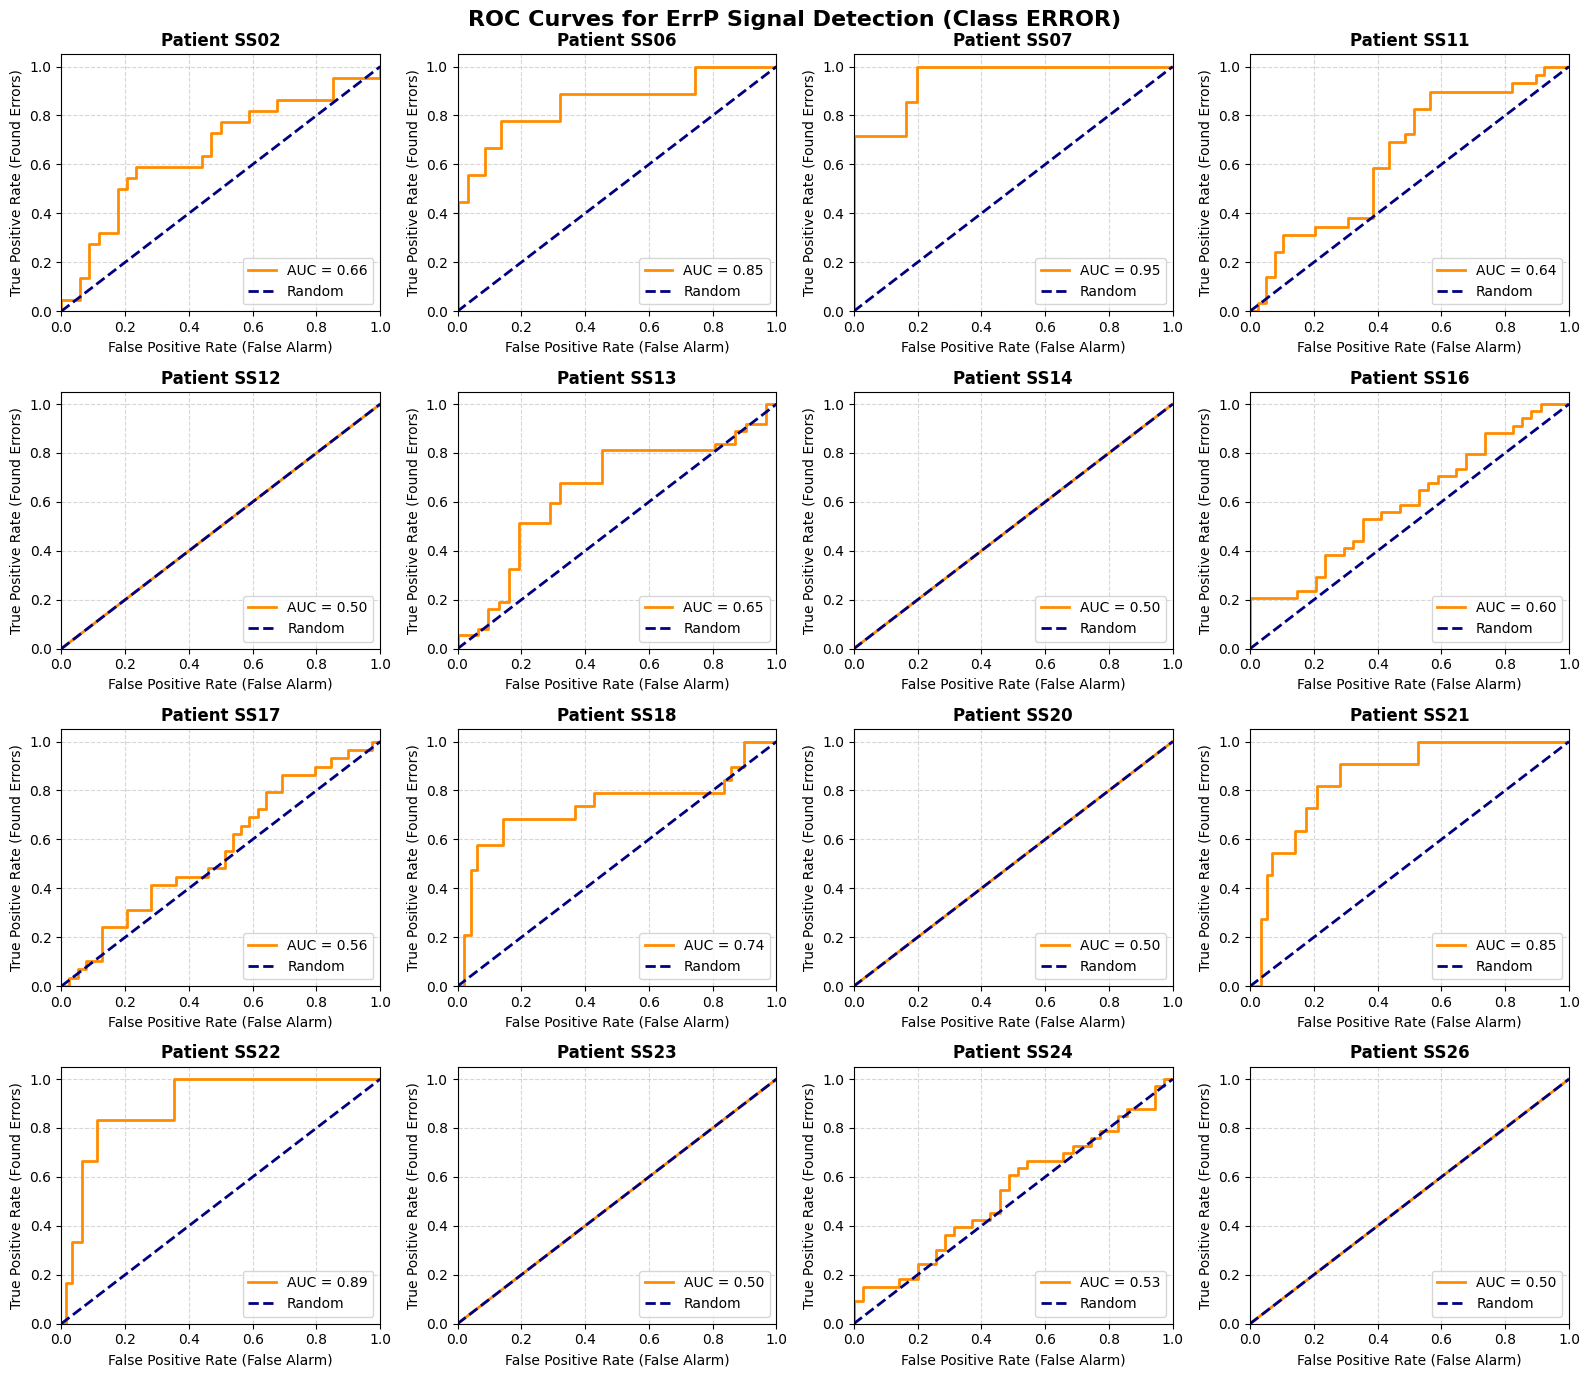

In [13]:
n_subs = len(subjects)
ncols = min(4, n_subs) 
nrows = math.ceil(n_subs / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, subject_id in enumerate(subjects):
    X_sub = X_dict[subject_id]
    y_sub = y_dict[subject_id]

    split_idx = int(len(X_sub) * TRAIN_SIZE)
    
    # Chronological split
    X_train, y_train = X_sub[:split_idx], y_sub[:split_idx]
    X_test, y_test = X_sub[split_idx:], y_sub[split_idx:]
    
    # Train
    pipe.fit(X_train, y_train)
    y_scores = pipe.decision_function(X_test)
    
    # Calculate FPR, TPR and AUC for the ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, -y_scores, pos_label=0)
    roc_auc = auc(fpr, tpr)
    
    # Visualization
    ax = axes[i]
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (False Alarm)')
    ax.set_ylabel('True Positive Rate (Found Errors)')
    ax.set_title(f'Patient S{subject_id}', fontweight='bold')
    ax.legend(loc="lower right")
    ax.grid(True, linestyle='--', alpha=0.5)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.suptitle('ROC Curves for ErrP Signal Detection (Class ERROR)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Cross-subject

In [82]:
for test_subject in subjects:
    X_train = np.concatenate([X_dict[subject_id] for s in subjects if s != test_subject], axis=0)
    y_train = np.concatenate([y_dict[subject_id] for s in subjects if s != test_subject], axis=0)
    X_test = X_dict[test_subject]
    
    pipe.fit(X_train, y_train)
    y_pred_cross = pipe.predict(X_test)
    for ytrue, ypred in zip(y_dict[test_subject], y_pred_cross):
        results['cross'].append({
            'subject': test_subject,
            'y_true': ytrue,
            'y_pred': ypred
        })

KeyboardInterrupt: 

### Save to CSV

In [14]:
pd.DataFrame(results['within']).to_csv("riemann_ner/results_within.csv", index=False)
#pd.DataFrame(results['cross']).to_csv("riemann_ner/results_cross.csv", index=False)

# Wizki

In [15]:
df_within = pd.read_csv("riemann_ner/results_within.csv")
#df_cross = pd.read_csv("riemann_ner/results_cross.csv")
results_table = []

In [16]:
results_within = calculate_metrics(df_within, 'Within-Subject')
#results_cross = calculate_metrics(df_cross, 'Cross-Subject')
#combined_results = results_within + results_cross
#df_results = pd.DataFrame(combined_results)
df_results = pd.DataFrame(results_within)

c:\Users\oskik\anaconda3\envs\cm\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\oskik\anaconda3\envs\cm\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [17]:
print("--- RESULTS TABLE ---")
print(df_results.to_string(index=False))

--- RESULTS TABLE ---
    Experiment Patient  Balanced Accuracy (%)  F1-Score (ErrP)  Precision (ErrP)  Recall (ErrP)
Within-Subject     S02                  60.70            0.586             0.472          0.773
Within-Subject     S06                  76.08            0.625             0.714          0.556
Within-Subject     S07                  83.26            0.667             0.625          0.714
Within-Subject     S11                  59.24            0.562             0.514          0.621
Within-Subject     S12                  50.00            0.729             0.574          1.000
Within-Subject     S13                  59.24            0.491             0.700          0.378
Within-Subject     S14                  50.00            0.000             0.000          0.000
Within-Subject     S16                  52.94            0.360             0.562          0.265
Within-Subject     S17                  50.00            0.598             0.426          1.000
Within-Subject    

In [18]:
pd.DataFrame(df_results.to_csv("riemann_ner/results.csv", index=False))

""


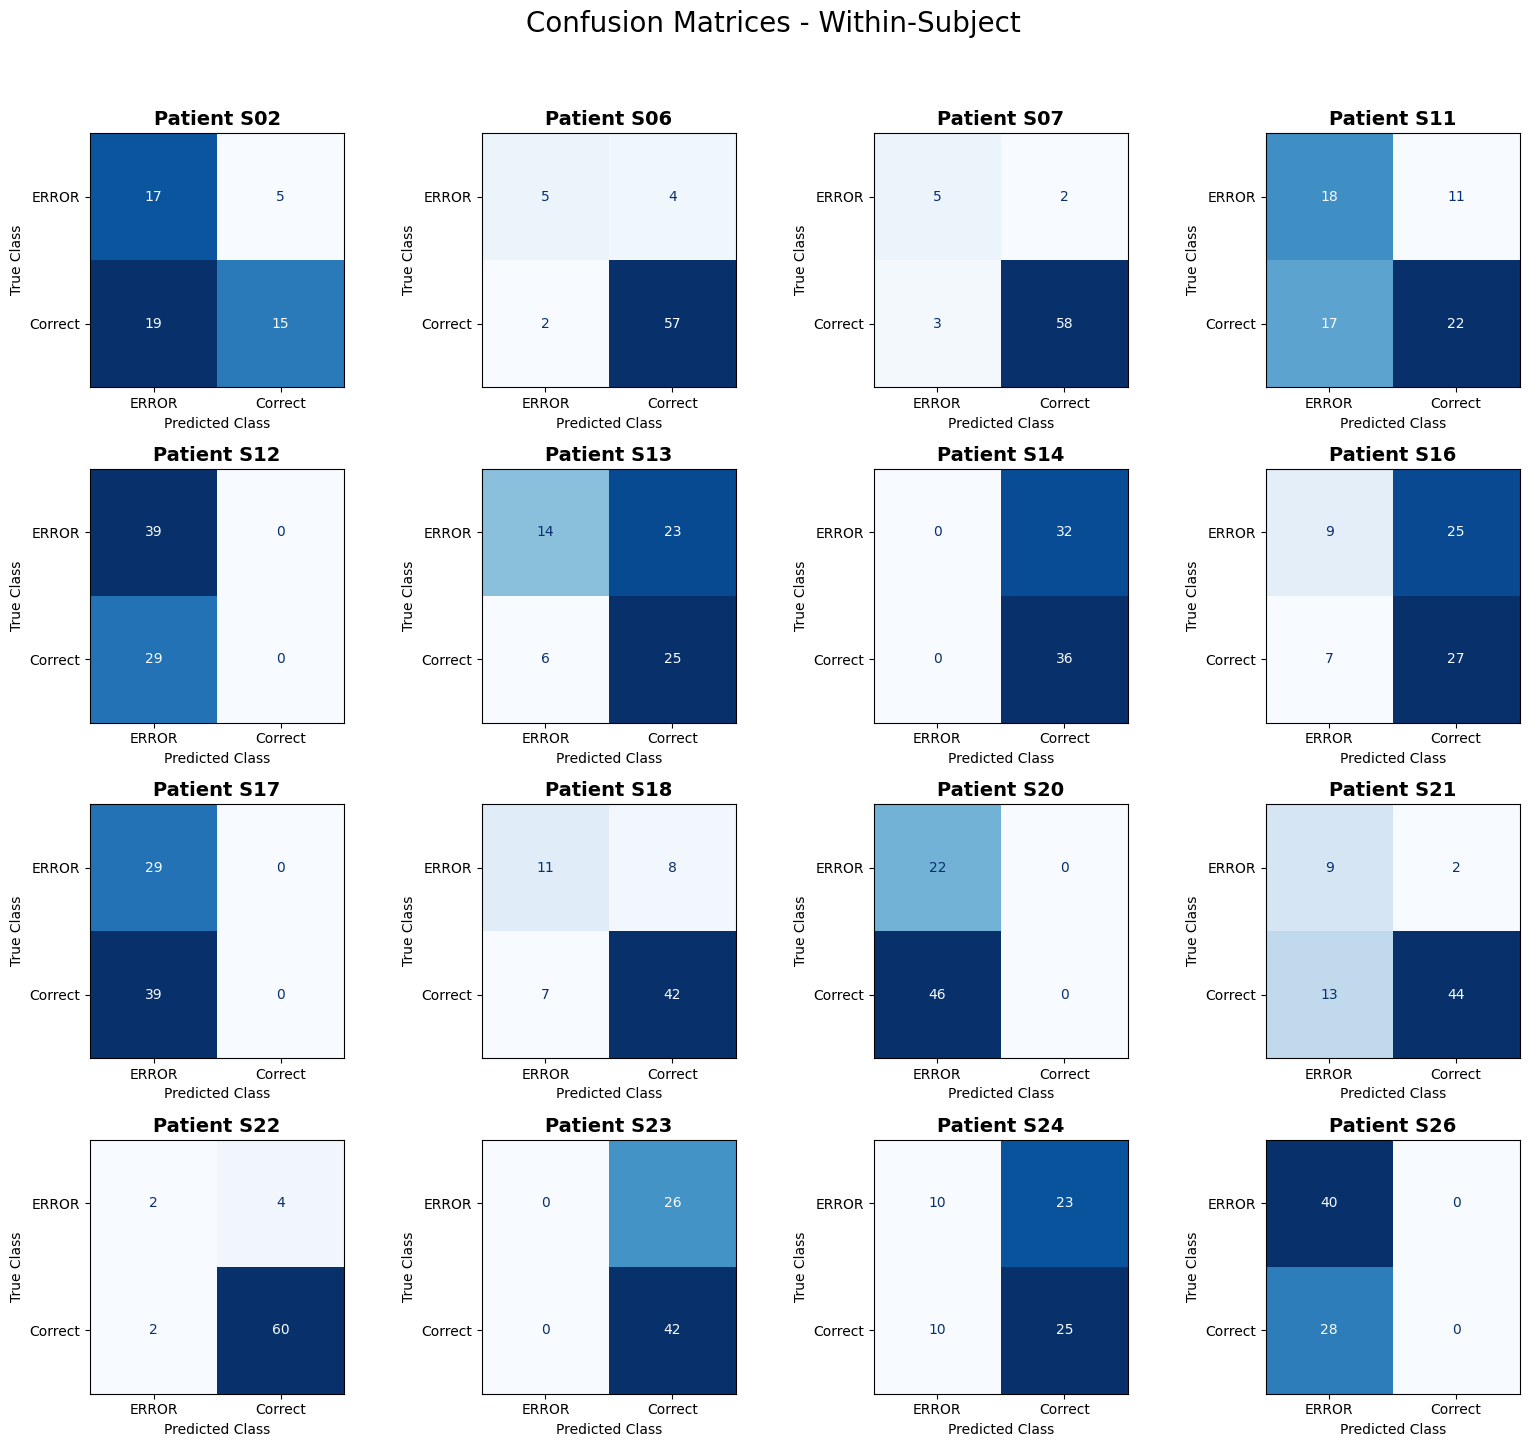

In [19]:
plot_confusion_matrices(df_within, 'Within-Subject', 'Riemann_Within_Subject.png')
#plot_confusion_matrices(df_cross, 'Cross-Subject', 'Riemann_Cross_Subject.png')

In [ ]:
# Create subplots for each metric
df = pd.read_csv("riemann_ner/results.csv")
metrics = df.columns[2:]
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

target_bar_index = 11
chosen_hex_color = "#e66101"

for i, metric in enumerate(metrics):
    sns.barplot(data=df, x='Patient', y=metric, hue='Experiment', ax=axes[i], palette=['#b2abd2', '#fdb863'])

    mean_within = df[df['Experiment'] == 'Within-Subject'][metric].mean()
    mean_cross = df[df['Experiment'] == 'Cross-Subject'][metric].mean()
    
    # Plot horizontal mean lines
    axes[i].axhline(mean_within, color='#b2abd2', linestyle='--', linewidth=0.8, zorder=0)
    axes[i].axhline(mean_cross, color='#fdb863', linestyle='--', linewidth=0.8, zorder=0)

    if metric == 'Recall (ErrP)':
        patches = axes[i].patches
        if len(patches) > target_bar_index:
            patches[target_bar_index].set_facecolor(chosen_hex_color)

    axes[i].set_title(metric, fontsize=10)
    axes[i].set_xlabel("Patient", fontsize=8)
    axes[i].set_ylabel("Score", fontsize=8)
    axes[i].tick_params(axis='both', which='major', labelsize=7)
    
    if i == 0:
        axes[i].legend(title='Experiment', fontsize=6, title_fontsize=8, loc='lower left')
    else:
        axes[i].get_legend().remove()

plt.tight_layout(pad=0.5, w_pad=2.0, h_pad=2.0)
plt.savefig("riemann_ner/results_vis.svg", dpi=300)

# MISC

## Chat

### Badanie ilościowe

In [ ]:
for subject_id in subjects:
    # Extract the shape of the data array
    total_trials, channels, time_samples = X_dict[subject_id].shape
    
    # Calculate how many trials go into the split
    split_idx = int(total_trials * TRAIN_SIZE)
    test_trials = total_trials - split_idx
    
    print(f"--- Pacjent {subject_id} ---")
    print(f"Całkowita liczba prób (Epochs): {total_trials}")
    print(f"Liczba kanałów (Channels):      {channels}")
    print(f"Próbki czasowe (Time samples):  {time_samples}")
    print(f"  -> Trening (Kalibracja):      {split_idx} prób")
    print(f"  -> Test (Sterowanie):         {test_trials} prób\n")

--- Pacjent S02 ---
Całkowita liczba prób (Epochs): 280
Liczba kanałów (Channels):      56
Próbki czasowe (Time samples):  51
  -> Trening (Kalibracja):      224 prób
  -> Test (Sterowanie):         56 prób

--- Pacjent S06 ---
Całkowita liczba prób (Epochs): 340
Liczba kanałów (Channels):      56
Próbki czasowe (Time samples):  51
  -> Trening (Kalibracja):      272 prób
  -> Test (Sterowanie):         68 prób

--- Pacjent S07 ---
Całkowita liczba prób (Epochs): 340
Liczba kanałów (Channels):      56
Próbki czasowe (Time samples):  51
  -> Trening (Kalibracja):      272 prób
  -> Test (Sterowanie):         68 prób

--- Pacjent S11 ---
Całkowita liczba prób (Epochs): 340
Liczba kanałów (Channels):      56
Próbki czasowe (Time samples):  51
  -> Trening (Kalibracja):      272 prób
  -> Test (Sterowanie):         68 prób

--- Pacjent S12 ---
Całkowita liczba prób (Epochs): 340
Liczba kanałów (Channels):      56
Próbki czasowe (Time samples):  51
  -> Trening (Kalibracja):      272 prób
 

### Even bigger GridSearch

In [98]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

from pyriemann.estimation import XdawnCovariances
from pyriemann.tangentspace import TangentSpace
from pyriemann.classification import MDM

from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score, make_scorer

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 1. Load Data
print("Loading preprocessed data...")
X_loaded = np.load('preprocessing/X_data_riemann_ner.npz')
y_loaded = np.load('preprocessing/y_data_riemann_ner.npz')

subjects = sorted(list(X_loaded.files))
X_dict = {sub: X_loaded[sub] for sub in subjects}
y_dict = {sub: y_loaded[sub] for sub in subjects}

print(f"Loaded {len(subjects)} subjects.")

# 2. Define Scorers
scoring = {
    'bal_acc': make_scorer(balanced_accuracy_score),
    'f1_errp': make_scorer(f1_score, pos_label=0) # Assuming 0 is the ErrP/Error class
}

# 3. Define the Pipelines to Compare
# BASELINE: Your current setup
pipeline_baseline = Pipeline([
    ('xdawn', XdawnCovariances(nfilter=4, estimator='lwf', xdawn_estimator='lwf')), 
    ('ts', TangentSpace(metric='riemann')),
    ('clf', LogisticRegression(
        class_weight='balanced', 
        solver='saga', 
        penalty='elasticnet', 
        l1_ratio=0.5, # 50% L1, 50% L2
        C=1.0, 
        random_state=42,
        max_iter=5000
    ))
])

# VARIANT 1: Adding StandardScaler before the SVM
pipeline_variant = Pipeline([
    ('xdawn', XdawnCovariances(nfilter=4, estimator='lwf', xdawn_estimator='lwf')), 
    ('ts', TangentSpace(metric='riemann')),
    ('clf', LogisticRegression(
        class_weight='balanced', 
        solver='saga', 
        penalty='elasticnet', 
        l1_ratio=0.5, # 50% L1, 50% L2
        C=0.01, 
        random_state=42,
        max_iter=5000
    ))
])

# 4. Evaluation Loop
results = []
tscv = StratifiedKFold(n_splits=5) # 5-fold chronological split

print("\nStarting evaluation (this may take a few minutes)...")
for sub in subjects:
    X_sub = X_dict[sub]
    y_sub = y_dict[sub]
    
    # Evaluate Baseline
    cv_base = cross_validate(pipeline_baseline, X_sub, y_sub, cv=tscv, scoring=scoring, n_jobs=-1)
    base_f1 = np.mean(cv_base['test_f1_errp'])
    
    # Evaluate Variant
    cv_var = cross_validate(pipeline_variant, X_sub, y_sub, cv=tscv, scoring=scoring, n_jobs=-1)
    var_f1 = np.mean(cv_var['test_f1_errp'])
    
    results.append({
        'Subject': sub,
        'Baseline_F1': base_f1,
        'Variant_F1': var_f1,
        'Improvement': var_f1 - base_f1
    })

# 5. Analyze Results
df_results = pd.DataFrame(results)

# Calculate Win Rate
wins = (df_results['Improvement'] > 0).sum()
losses = (df_results['Improvement'] < 0).sum()
ties = (df_results['Improvement'] == 0).sum()

# Statistical Significance (Wilcoxon Test)
# Null hypothesis: The median difference between pairs is zero.
stat, p_value = wilcoxon(df_results['Baseline_F1'], df_results['Variant_F1'])

print("\n" + "="*40)
print("             RESULTS")
print("="*40)
print(df_results[['Subject', 'Baseline_F1', 'Variant_F1', 'Improvement']].round(4).to_string(index=False))
print("-" * 40)
print(f"Mean Baseline F1: {df_results['Baseline_F1'].mean():.4f}")
print(f"Mean Variant F1:  {df_results['Variant_F1'].mean():.4f}")
print(f"Win/Loss/Tie:     {wins} Wins, {losses} Losses, {ties} Ties")
print(f"Wilcoxon p-value: {p_value:.4f}")

if p_value < 0.05 and wins > losses:
    print("\n✅ CONCLUSION: The variant is STATISTICALLY BETTER. Keep this change!")
elif p_value < 0.05 and losses > wins:
    print("\n❌ CONCLUSION: The variant is STATISTICALLY WORSE. Discard this change.")
else:
    print("\n⚠️ CONCLUSION: No statistically significant difference. The change is neutral (p >= 0.05).")

Loading preprocessed data...
Loaded 16 subjects.

Starting evaluation (this may take a few minutes)...

             RESULTS
Subject  Baseline_F1  Variant_F1  Improvement
    S02       0.4975      0.4513      -0.0462
    S06       0.2561      0.1439      -0.1123
    S07       0.3371      0.1071      -0.2300
    S11       0.4470      0.5055       0.0585
    S12       0.4863      0.4926       0.0063
    S13       0.5065      0.5174       0.0108
    S14       0.4807      0.3226      -0.1581
    S16       0.4615      0.2213      -0.2402
    S17       0.5348      0.4044      -0.1304
    S18       0.4144      0.3009      -0.1136
    S20       0.4221      0.2831      -0.1389
    S21       0.4476      0.0324      -0.4152
    S22       0.7044      0.3417      -0.3627
    S23       0.4389      0.2087      -0.2302
    S24       0.5292      0.0909      -0.4383
    S26       0.4749      0.6373       0.1624
----------------------------------------
Mean Baseline F1: 0.4649
Mean Variant F1:  0.3163
Wi

## Parameter GridSearch for worst patients

In [6]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, f1_score
from pyriemann.estimation import XdawnCovariances
from pyriemann.tangentspace import TangentSpace


TRAIN_SIZE = 0.8
X_dict = {}
y_dict = {}    

print("Loading preprocessed data from .npz files...")

X_loaded = np.load('preprocessing/X_data_riemann_ner.npz')
y_loaded = np.load('preprocessing/y_data_riemann_ner.npz')

# Convert the loaded NpzFiles back into standard Python dictionaries
X_dict = {subject: X_loaded[subject] for subject in X_loaded.files}
y_dict = {subject: y_loaded[subject] for subject in y_loaded.files}

# Recreate the subjects list based on the loaded data keys
subjects = sorted(list(X_dict.keys()))

# Worst-performing patients based on baseline F1 / Balanced Accuracy
target_subjects = ['S06', 'S07', 'S13', 'S14', 'S16', 'S18', 'S22', 'S23', 'S24']

# Define multiple scorers. 'roc_auc' is built-in; custom scorer for ErrP F1 (pos_label=0)
scoring = {
    'F1_ErrP': make_scorer(f1_score, pos_label=0),
    'AUC': 'roc_auc'
}

# Riemannian pipeline
pipe = Pipeline([
    ('xdawn', XdawnCovariances(estimator='lwf', xdawn_estimator='lwf')), 
    ('ts', TangentSpace(metric='riemann')),
    ('clf', LogisticRegression(class_weight='balanced', solver='saga', penalty='elasticnet', random_state=42, max_iter=3000))
])

# Expanded Hyperparameter Grid
param_grid = {
    # Test fewer filters (1) and more filters (10, 12)
    # Note: nfilter is per class, so 1 means 2 total spatial filters.
    'xdawn__nfilter': [1, 2, 4, 8, 10, 12], 
    
    # Expand C to have stronger regularization (0.01) and weaker regularization (20.0, 50.0)
    'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0],
    
    # Test pure L2 (0.0), pure L1 (1.0), and closer to the edges
    'clf__l1_ratio': [0.0, 0.1, 0.2, 0.5, 0.8, 0.9, 1.0]
}

cv_strategy = TimeSeriesSplit(n_splits=4)

# Set refit='AUC' to select the best model based exclusively on AUC
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scoring,
    refit='AUC',
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=False
)

results_list = []

# Dictionaries to store the scores for every configuration
all_subject_f1 = {}
params_list = None

for subject_id in target_subjects:
    print(f"Fitting GridSearch for Patient {subject_id}...")
    
    X_sub = X_dict[subject_id]
    y_sub = y_dict[subject_id]
    
    # Chronological split
    split_idx = int(len(X_sub) * 0.75)
    X_train, y_train = X_sub[:split_idx], y_sub[:split_idx]
    
    # Fit the grid search on the training split
    grid_search.fit(X_train, y_train)
    
    # On the first loop, extract the parameter combinations list
    if params_list is None:
        params_list = grid_search.cv_results_['params']
        
    # Store the array of F1 scores (one score per parameter combination)
    all_subject_f1[subject_id] = grid_search.cv_results_['mean_test_F1_ErrP']

# --- Compile Detailed Results ---
# Convert the list of parameter dictionaries to a DataFrame
df_details = pd.DataFrame(params_list)

# Add each subject's CV F1 score as a new column
for subject_id in target_subjects:
    df_details[f"{subject_id}_F1"] = all_subject_f1[subject_id]

# Calculate the mean F1 score across all evaluated subjects for each param combination
subject_cols = [f"{s}_F1" for s in target_subjects]
df_details['Mean_F1'] = df_details[subject_cols].mean(axis=1)

# Sort the table so the best average F1 is at the top
df_details = df_details.sort_values(by='Mean_F1', ascending=False).reset_index(drop=True)

# Save to CSV so you can inspect it in Excel/Jupyter easily
df_details.to_csv("riemann_ner/grid_search_detailed_results.csv", index=False)

print("\n" + "="*80)
print("DETAILED RESULTS FOR EVERY PARAMETER COMBINATION (Top 10 printed)")
print("="*80)
print(df_details.head(10).to_string())

print("\n" + "="*80)
print("BEST GLOBAL PARAMETERS (Based on Mean F1 across all subjects)")
print("="*80)

# Extract the best configuration (the first row after sorting by Mean_F1)
best_row = df_details.iloc[0]
best_params = {k: best_row[k] for k in param_grid.keys()}

print(f"Best Mean F1:  {best_row['Mean_F1']:.4f}")
print(f"Best Params:   {best_params}")

Loading preprocessed data from .npz files...
Fitting GridSearch for Patient S06...
Fitting GridSearch for Patient S07...
Fitting GridSearch for Patient S13...
Fitting GridSearch for Patient S14...
Fitting GridSearch for Patient S16...
Fitting GridSearch for Patient S18...
Fitting GridSearch for Patient S22...
Fitting GridSearch for Patient S23...
Fitting GridSearch for Patient S24...

DETAILED RESULTS FOR EVERY PARAMETER COMBINATION (Top 10 printed)
   clf__C  clf__l1_ratio  xdawn__nfilter    S06_F1    S07_F1    S13_F1    S14_F1    S16_F1    S18_F1    S22_F1    S23_F1    S24_F1   Mean_F1
0    0.10            0.8               8  0.171429  0.693651  0.660606  0.292607  0.597085  0.442469  0.238095  0.480223  0.433333  0.445500
1   10.00            0.8               2  0.183333  0.365079  0.539075  0.458509  0.636369  0.521875  0.323864  0.406881  0.553655  0.443182
2    0.10            0.5               8  0.154762  0.565079  0.592576  0.421270  0.641572  0.397768  0.291667  0.455673  0